# SP5 — Finite State Markov Chain: Monte Carlo vs Kernel VAR
### Sequential Prediction Course Project

**Goal:** Given a trajectory from a finite-state Markov chain, estimate the
**conditional expected next state** $\mathbb{E}[X_{t+1} \mid X_t = x]$ for every
starting state $x$. Compare two methods:

| Method | Idea | Key parameters |
|--------|------|----------------|
| **Monte Carlo** | Empirical average of next states for each starting state | — (or optional Laplace smoothing) |
| **Kernel VAR** | Kernel regression $(x_t \to x_{t+1})$ with RBF kernel | bandwidth $\sigma$, regularization $\lambda$ |

**Protocol:** 80% train / 10% validation (hyperparameter selection) / 10% test.
Metric: mean squared prediction error $\frac{1}{n}\sum_t (X_{t+1} - \hat{f}(X_t))^2$.

---
**How to use this notebook:**
1. Edit the `🔧 CONFIGURATION` cell to choose your Markov chain and experiment settings.
2. Run all cells (`Kernel > Restart & Run All`).
3. Scroll to the results and plots. Then go back and tweak parameters!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
print('Imports OK ✓')

Imports OK ✓


---
## 🔧 CONFIGURATION
**Edit this cell to change the Markov chain and experiment settings.**

In [2]:
# ═══════════════════════════════════════════════════════════════
# 🔧 CONFIGURATION — Edit freely!
# ═══════════════════════════════════════════════════════════════

# ── Markov chain ────────────────────────────────────────────────

# Preset 1: Near-cycle (strong directional flow 0→1→2→3→0)
PRESET_CYCLE = np.array([
    [0.05, 0.85, 0.05, 0.05],
    [0.05, 0.05, 0.85, 0.05],
    [0.05, 0.05, 0.05, 0.85],
    [0.85, 0.05, 0.05, 0.05],
])

# Preset 2: Two clusters (states {0,1} ↔ states {2,3} rarely mix)
PRESET_CLUSTERS = np.array([
    [0.45, 0.45, 0.05, 0.05],
    [0.45, 0.45, 0.05, 0.05],
    [0.05, 0.05, 0.45, 0.45],
    [0.05, 0.05, 0.45, 0.45],
])

# Preset 3: Sticky states (tends to stay in the same state)
PRESET_STICKY = np.array([
    [0.70, 0.15, 0.10, 0.05],
    [0.10, 0.70, 0.15, 0.05],
    [0.05, 0.10, 0.70, 0.15],
    [0.15, 0.05, 0.10, 0.70],
])

# Preset 4: Nearly uniform (very random, hard to predict)
PRESET_UNIFORM = np.array([
    [0.25, 0.25, 0.25, 0.25],
    [0.25, 0.25, 0.25, 0.25],
    [0.25, 0.25, 0.25, 0.25],
    [0.25, 0.25, 0.25, 0.25],
])

# Custom: define your own N×N matrix (rows must sum to 1)
PRESET_CUSTOM = np.array([
    [0.60, 0.30, 0.10],
    [0.20, 0.60, 0.20],
    [0.10, 0.30, 0.60],
])

# ──────────────────────────────────────────────────────────────
# ▶  SET YOUR CHAIN HERE
P_TRUE = PRESET_STICKY
# ──────────────────────────────────────────────────────────────

N_STATES = P_TRUE.shape[0]   # derived automatically

# ── Trajectory & split ──────────────────────────────────────────
T          = 3000   # total trajectory length  (try 500, 1000, 5000, 10000)
TRAIN_FRAC = 0.80
VAL_FRAC   = 0.10
# test fraction = 1 - TRAIN_FRAC - VAL_FRAC  (= 0.10 by default)

# ── Kernel VAR hyperparameter grid ─────────────────────────────
# sigma: RBF bandwidth (controls how much nearby states influence each other)
# lam:   regularization strength
SIGMA_GRID  = [0.3, 0.7, 1.0, 2.0, 5.0]
LAMBDA_GRID = [1e-4, 1e-3, 1e-2, 0.1, 1.0]

# ── Repetitions ────────────────────────────────────────────────
N_RUNS     = 20    # number of independent random trajectories to average over
BASE_SEED  = 42

# ── T-sweep experiment ──────────────────────────────────────────
T_VALUES   = [200, 500, 1000, 2000, 5000]   # values to try in the T-sweep

# ── Sanity check ───────────────────────────────────────────────
assert np.allclose(P_TRUE.sum(axis=1), 1.0), "Rows of P_TRUE must sum to 1!"
print(f'Chain: {N_STATES} states | T={T} | {int(T*TRAIN_FRAC)} train / '
      f'{int(T*VAL_FRAC)} val / {T - int(T*TRAIN_FRAC) - int(T*VAL_FRAC)} test')
print(f'Runs: {N_RUNS}  |  Grid: {len(SIGMA_GRID)}×{len(LAMBDA_GRID)} = {len(SIGMA_GRID)*len(LAMBDA_GRID)} combos')
print('Configuration OK ✓')

Chain: 4 states | T=3000 | 2400 train / 300 val / 300 test
Runs: 20  |  Grid: 5×5 = 25 combos
Configuration OK ✓


---
## 🛠️ Core Functions

In [3]:
# ── Trajectory generation ───────────────────────────────────────────────────

def generate_trajectory(P, T, rng):
    """Generate a Markov chain trajectory of length T."""
    N = P.shape[0]
    X = np.zeros(T, dtype=int)
    X[0] = rng.integers(N)          # random start
    for t in range(1, T):
        X[t] = rng.choice(N, p=P[X[t-1]])
    return X


def split_trajectory(X, train_frac=0.8, val_frac=0.1):
    """Split a trajectory into train / validation / test segments."""
    T = len(X)
    i1 = int(T * train_frac)
    i2 = int(T * (train_frac + val_frac))
    return X[:i1], X[i1:i2], X[i2:]


# ── Evaluation metric ───────────────────────────────────────────────────────

def mpe(X_segment, predict_fn):
    """
    Mean Prediction Error on a trajectory segment.
    mpe = (1/n) Σ (X_{t+1} - f(X_t))^2
    NaN predictions (unvisited states) are skipped.
    """
    inputs  = X_segment[:-1]
    targets = X_segment[1:].astype(float)
    preds   = np.array([predict_fn(x) for x in inputs])
    valid   = ~np.isnan(preds)
    if valid.sum() == 0:
        return np.nan
    return np.mean((targets[valid] - preds[valid]) ** 2)


# ── True conditional expectation (oracle / reference) ──────────────────────

def true_conditional_expectation(P):
    """
    E[X_{t+1} | X_t = x] = Σ_j  j * P[x, j]  for each state x.
    Returns an array of shape (N,).
    """
    states = np.arange(P.shape[0], dtype=float)
    return P @ states


def oracle_error(P, X_segment):
    """
    Error achieved by the TRUE conditional expectation (irreducible floor).
    This is the best any estimator can hope to achieve.
    """
    ce = true_conditional_expectation(P)
    return mpe(X_segment, lambda x: ce[x])


print('Core functions defined ✓')

Core functions defined ✓


---
## Method 1 — Monte Carlo Conditional Expectation

For each state $x$, the MC estimate is simply:
$$\hat{\mathbb{E}}[X_{t+1} \mid X_t = x] = \frac{\sum_{t\,:\,X_t = x} X_{t+1}}{\#\{t : X_t = x\}}$$

This is the **row-mean of the empirical transition matrix** — i.e., the sample mean of the
next-state distribution from $x$. No hyperparameters needed!

> 💡 **Why it works:** by the Law of Large Numbers, as the number of visits to $x$
> grows, the estimate converges to the true conditional expectation.

In [4]:
class MonteCarloCE:
    """
    Monte Carlo estimator of E[X_{t+1} | X_t = x].
    Fits on a trajectory segment; predicts for any state seen during training.
    """

    def __init__(self, n_states):
        self.n_states  = n_states
        self.estimates = None   # shape (N,) — NaN for unvisited states
        self.counts    = None   # how many times each state was visited

    def fit(self, X_train):
        counts = np.zeros(self.n_states)
        sums   = np.zeros(self.n_states)
        for t in range(len(X_train) - 1):
            s, s_next  = X_train[t], X_train[t + 1]
            counts[s] += 1
            sums[s]   += s_next
        self.counts    = counts
        # NaN for states never visited in training
        self.estimates = np.where(counts > 0, sums / counts, np.nan)
        return self

    def predict(self, x):
        return self.estimates[x]

    def mpe(self, X_segment):
        return mpe(X_segment, self.predict)


print('MonteCarloCE defined ✓')

MonteCarloCE defined ✓


---
## Method 2 — Kernel VAR ($p = 1$)

We treat prediction as **kernel regression** on the autoregressive dataset
$\{(X_t, X_{t+1})\}_{t=1}^{T_{\text{train}}-1}$.

Using a **Gaussian (RBF) kernel** $k(x, x') = \exp\!\left(-\frac{(x-x')^2}{2\sigma^2}\right)$,
the representer theorem gives:
$$\hat{f}(x) = \sum_{t} \alpha_t\, k(x, X_t), \qquad
\boldsymbol{\alpha} = (K + \lambda n I)^{-1}\mathbf{y}$$
where $K_{ts} = k(X_t, X_s)$ and $y_t = X_{t+1}$.

**Hyperparameters** ($\sigma$, $\lambda$) are chosen by minimizing
the MPE on the **validation** set.

> ⚠️ **Note on the RBF kernel and discrete states:**  
> The RBF kernel treats states as ordered numbers on the real line.
> This means *state 1 and state 2 are considered similar*,
> regardless of the actual transition structure. This implicit assumption
> may help or hurt depending on whether the chain's dynamics respect this ordering.

In [5]:
class KernelVAR:
    """
    Kernel VAR (p=1) with Gaussian RBF kernel.
    States are treated as real numbers for the kernel computation.

    Parameters
    ----------
    n_states : int
    sigma    : float  — RBF bandwidth
    lam      : float  — regularization strength
    """

    def __init__(self, n_states, sigma=1.0, lam=1e-3):
        self.n_states = n_states
        self.sigma    = sigma
        self.lam      = lam

    # ── Internal helpers ──────────────────────────────────────────────

    def _rbf_matrix(self, X, Y=None):
        """Compute RBF kernel matrix between rows of X and Y (or X,X)."""
        if Y is None:
            Y = X
        X = np.asarray(X, dtype=float)
        Y = np.asarray(Y, dtype=float)
        diff = X[:, None] - Y[None, :]
        return np.exp(-diff**2 / (2 * self.sigma**2))

    # ── Public API ────────────────────────────────────────────────────

    def fit(self, X_train):
        inputs  = X_train[:-1].astype(float)
        targets = X_train[1:].astype(float)
        n       = len(inputs)

        K           = self._rbf_matrix(inputs)
        self.alpha  = np.linalg.solve(K + self.lam * n * np.eye(n), targets)
        self._train_inputs = inputs

        # Pre-compute prediction for every state integer (fast at eval time)
        states            = np.arange(self.n_states, dtype=float)
        K_pred            = self._rbf_matrix(states, inputs)
        self._state_preds = K_pred @ self.alpha   # shape (N,)
        return self

    def predict(self, x):
        return self._state_preds[int(x)]

    def mpe(self, X_segment):
        return mpe(X_segment, self.predict)


# ── Grid search for best (sigma, lambda) on validation set ──────────────────

def tune_kernel_var(X_train, X_val, n_states, sigma_grid, lambda_grid, verbose=False):
    """
    Exhaustive grid search over sigma x lambda.
    Returns (best_sigma, best_lam, best_val_mpe, results_dict).
    """
    best_mpe    = np.inf
    best_params = (sigma_grid[0], lambda_grid[0])
    grid        = np.full((len(sigma_grid), len(lambda_grid)), np.nan)

    for i, sigma in enumerate(sigma_grid):
        for j, lam in enumerate(lambda_grid):
            model   = KernelVAR(n_states, sigma=sigma, lam=lam)
            model.fit(X_train)
            val_mpe = model.mpe(X_val)
            grid[i, j] = val_mpe
            if val_mpe < best_mpe:
                best_mpe    = val_mpe
                best_params = (sigma, lam)
            if verbose:
                print(f'  sigma={sigma:.2f}  lam={lam:.0e}  val_mpe={val_mpe:.4f}')

    return best_params[0], best_params[1], best_mpe, grid


print('KernelVAR + tune_kernel_var defined ✓')

KernelVAR + tune_kernel_var defined ✓


---
## 👁️ Visualise the Chain

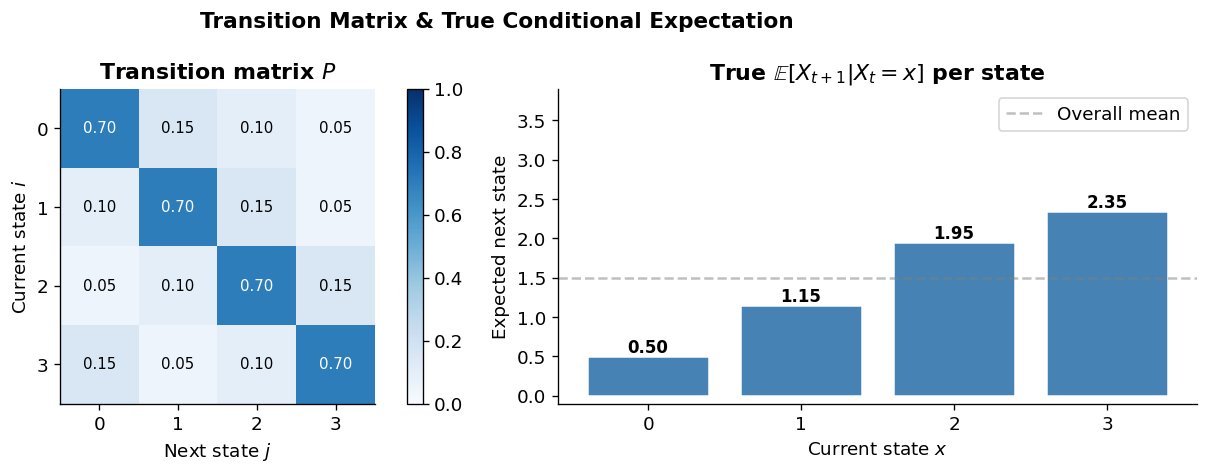

In [6]:
def plot_chain_overview(P, title='Transition Matrix & True Conditional Expectation'):
    N  = P.shape[0]
    ce = true_conditional_expectation(P)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: heatmap of P
    im = axes[0].imshow(P, cmap='Blues', vmin=0, vmax=1)
    axes[0].set_title('Transition matrix $P$', fontweight='bold')
    axes[0].set_xlabel('Next state $j$')
    axes[0].set_ylabel('Current state $i$')
    axes[0].set_xticks(range(N));  axes[0].set_yticks(range(N))
    plt.colorbar(im, ax=axes[0], fraction=0.046)
    for i in range(N):
        for j in range(N):
            axes[0].text(j, i, f'{P[i,j]:.2f}',
                         ha='center', va='center',
                         color='white' if P[i,j] > 0.5 else 'black', fontsize=9)

    # Right: true conditional expectation per state
    axes[1].bar(range(N), ce, color='steelblue', edgecolor='white', linewidth=1.5)
    axes[1].set_title('True $\mathbb{E}[X_{t+1} | X_t = x]$ per state', fontweight='bold')
    axes[1].set_xlabel('Current state $x$')
    axes[1].set_ylabel('Expected next state')
    axes[1].set_xticks(range(N))
    axes[1].set_ylim(-0.1, N - 0.1)
    axes[1].axhline(y=(N-1)/2, color='grey', linestyle='--', alpha=0.5, label='Overall mean')
    axes[1].legend()
    for x, v in enumerate(ce):
        axes[1].text(x, v + 0.05, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_chain_overview(P_TRUE)

---
## 🔬 Single Run — Step by Step

Trajectory length : 3000
Train : 2400   Val : 300   Test : 300
State frequencies in train: {0: 599, 1: 539, 2: 708, 3: 554}


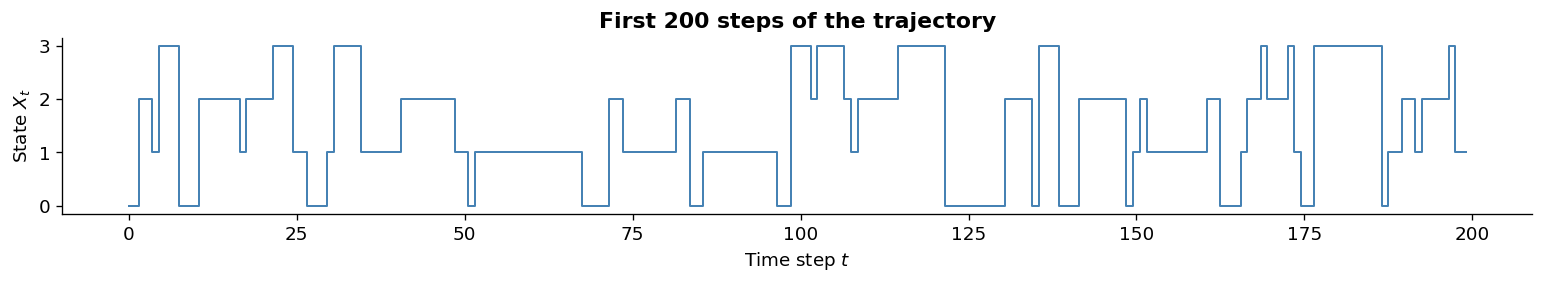

In [7]:
# Generate one trajectory and split it
rng          = np.random.default_rng(BASE_SEED)
X            = generate_trajectory(P_TRUE, T, rng)
X_train, X_val, X_test = split_trajectory(X, TRAIN_FRAC, VAL_FRAC)

print(f'Trajectory length : {T}')
print(f'Train : {len(X_train)}   Val : {len(X_val)}   Test : {len(X_test)}')
print(f'State frequencies in train: { {s: int(np.sum(X_train==s)) for s in range(N_STATES)} }')

# Quick plot of first 200 steps
fig, ax = plt.subplots(figsize=(13, 2.5))
ax.step(range(200), X[:200], where='mid', color='steelblue', linewidth=1.2)
ax.set_xlabel('Time step $t$')
ax.set_ylabel('State $X_t$')
ax.set_yticks(range(N_STATES))
ax.set_title('First 200 steps of the trajectory', fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# ── Fit Monte Carlo ───────────────────────────────────────────────────────
mc = MonteCarloCE(N_STATES)
mc.fit(X_train)

print('Monte Carlo estimates:')
ce_true = true_conditional_expectation(P_TRUE)
for s in range(N_STATES):
    count = int(mc.counts[s])
    est   = mc.estimates[s]
    truth = ce_true[s]
    print(f'  State {s}: visits={count:4d}  estimate={est:.4f}  true={truth:.4f}  '
          f'error={abs(est-truth):.4f}')

Monte Carlo estimates:
  State 0: visits= 599  estimate=0.4708  true=0.5000  error=0.0292
  State 1: visits= 538  estimate=1.2082  true=1.1500  error=0.0582
  State 2: visits= 708  estimate=1.9534  true=1.9500  error=0.0034
  State 3: visits= 554  estimate=2.3502  true=2.3500  error=0.0002


Grid searching (sigma, lambda)...
Best sigma=2.0, lam=1e-04  →  val MPE=0.7111


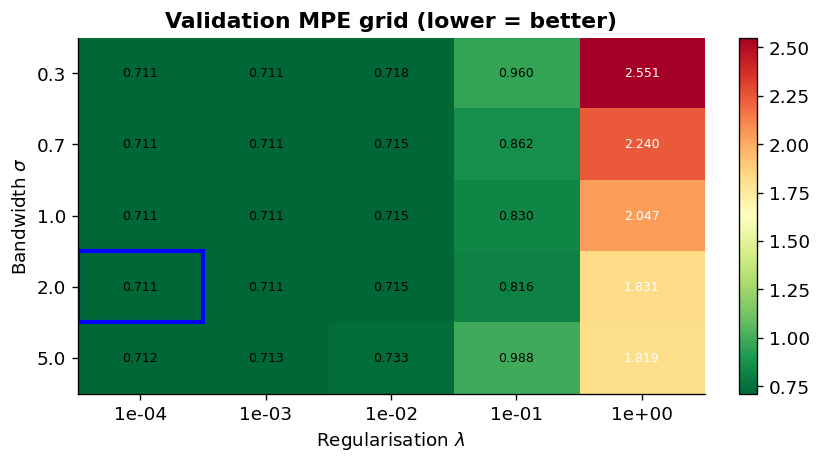

In [9]:
# ── Tune and fit Kernel VAR ───────────────────────────────────────────────
print('Grid searching (sigma, lambda)...')
best_sigma, best_lam, best_val_mpe, grid_results = tune_kernel_var(
    X_train, X_val, N_STATES, SIGMA_GRID, LAMBDA_GRID
)
print(f'Best sigma={best_sigma}, lam={best_lam:.0e}  →  val MPE={best_val_mpe:.4f}')

# Visualise the hyperparameter grid
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(grid_results, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(LAMBDA_GRID)))
ax.set_xticklabels([f'{l:.0e}' for l in LAMBDA_GRID])
ax.set_yticks(range(len(SIGMA_GRID)))
ax.set_yticklabels([str(s) for s in SIGMA_GRID])
ax.set_xlabel('Regularisation $\lambda$')
ax.set_ylabel('Bandwidth $\sigma$')
ax.set_title('Validation MPE grid (lower = better)', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)
for i in range(len(SIGMA_GRID)):
    for j in range(len(LAMBDA_GRID)):
        ax.text(j, i, f'{grid_results[i,j]:.3f}',
                ha='center', va='center', fontsize=7.5,
                color='white' if grid_results[i,j] > np.nanmean(grid_results) else 'black')
# Mark best
bi = SIGMA_GRID.index(best_sigma)
bj = LAMBDA_GRID.index(best_lam)
ax.add_patch(plt.Rectangle((bj-0.5, bi-0.5), 1, 1, fill=False, edgecolor='blue', linewidth=2.5))
plt.tight_layout()
plt.show()

# Refit with best params
kvar = KernelVAR(N_STATES, sigma=best_sigma, lam=best_lam)
kvar.fit(X_train)

  Oracle (true CE)  : 0.6943  ← irreducible floor
  Monte Carlo       : 0.6934  (+-0.0009 above oracle)
  Kernel VAR        : 0.6933  (+-0.0009 above oracle)
  → Kernel VAR wins by 0.0000


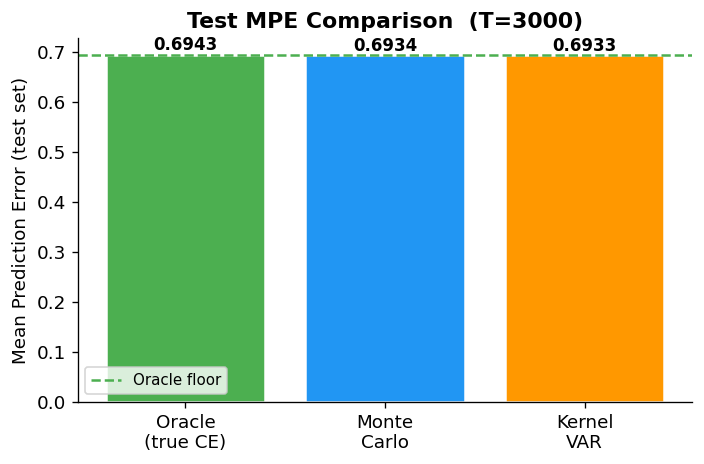

In [10]:
# ── Compare on test set ─────────────────────────────────────────────────
mc_test_mpe   = mc.mpe(X_test)
kvar_test_mpe = kvar.mpe(X_test)
oracle_mpe    = oracle_error(P_TRUE, X_test)

print('='*55)
print(f'  Oracle (true CE)  : {oracle_mpe:.4f}  ← irreducible floor')
print(f'  Monte Carlo       : {mc_test_mpe:.4f}  '
      f'(+{mc_test_mpe - oracle_mpe:.4f} above oracle)')
print(f'  Kernel VAR        : {kvar_test_mpe:.4f}  '
      f'(+{kvar_test_mpe - oracle_mpe:.4f} above oracle)')
print('='*55)

winner = 'Monte Carlo' if mc_test_mpe < kvar_test_mpe else 'Kernel VAR'
margin = abs(mc_test_mpe - kvar_test_mpe)
print(f'  → {winner} wins by {margin:.4f}')

# ── Bar chart summary ──────────────────────────────────────────────────────
methods = ['Oracle\n(true CE)', 'Monte\nCarlo', 'Kernel\nVAR']
values  = [oracle_mpe, mc_test_mpe, kvar_test_mpe]
colors  = ['#4CAF50', '#2196F3', '#FF9800']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(methods, values, color=colors, edgecolor='white', linewidth=1.5)
ax.axhline(oracle_mpe, color='#4CAF50', linestyle='--', linewidth=1.5, label='Oracle floor')
ax.set_ylabel('Mean Prediction Error (test set)')
ax.set_title(f'Test MPE Comparison  (T={T})', fontweight='bold')
ax.legend(fontsize=9)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002, f'{val:.4f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

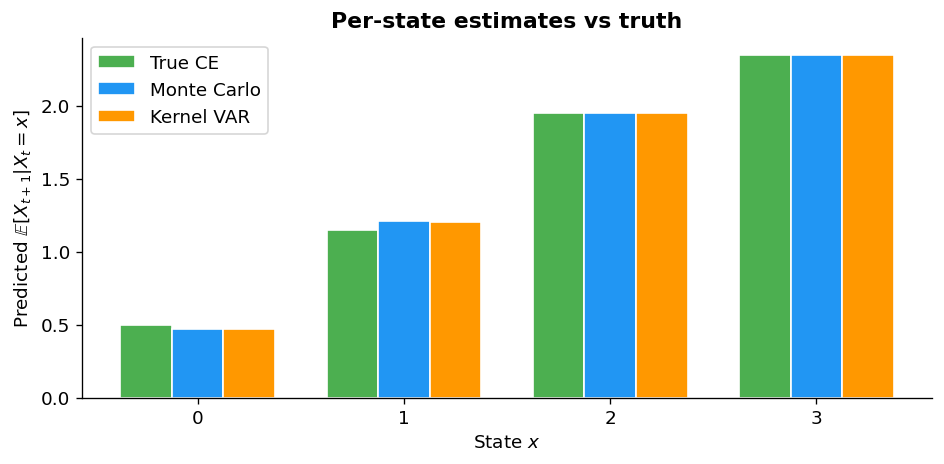

In [11]:
# ── Per-state comparison ─────────────────────────────────────────────────
states   = np.arange(N_STATES)
mc_preds = np.array([mc.predict(x) for x in states])
kv_preds = np.array([kvar.predict(x) for x in states])
ce_true_vals = true_conditional_expectation(P_TRUE)

fig, ax = plt.subplots(figsize=(8, 4))
width = 0.25
ax.bar(states - width, ce_true_vals, width=width, label='True CE', color='#4CAF50', edgecolor='white')
ax.bar(states,         mc_preds,     width=width, label='Monte Carlo', color='#2196F3', edgecolor='white')
ax.bar(states + width, kv_preds,     width=width, label='Kernel VAR', color='#FF9800', edgecolor='white')
ax.set_xlabel('State $x$')
ax.set_ylabel('Predicted $\mathbb{E}[X_{t+1}|X_t=x]$')
ax.set_title('Per-state estimates vs truth', fontweight='bold')
ax.set_xticks(states)
ax.legend()
plt.tight_layout()
plt.show()

---
## 📊 Experiment 1 — Multiple Runs (robustness to randomness)

Since the trajectory is random, a single experiment may be misleading.
We repeat the full pipeline $N_{\text{runs}}$ times and look at the
**distribution** of test MPE.

In [12]:
mc_test_mpes   = []
kvar_test_mpes = []
oracle_mpes    = []

for run in range(N_RUNS):
    rng_r = np.random.default_rng(BASE_SEED + run)
    X_r   = generate_trajectory(P_TRUE, T, rng_r)
    tr, va, te = split_trajectory(X_r, TRAIN_FRAC, VAL_FRAC)

    # MC
    mc_r = MonteCarloCE(N_STATES).fit(tr)

    # Kernel VAR — tune each run independently
    bs, bl, _, _ = tune_kernel_var(tr, va, N_STATES, SIGMA_GRID, LAMBDA_GRID)
    kv_r = KernelVAR(N_STATES, sigma=bs, lam=bl).fit(tr)

    mc_test_mpes.append(mc_r.mpe(te))
    kvar_test_mpes.append(kv_r.mpe(te))
    oracle_mpes.append(oracle_error(P_TRUE, te))

    if (run + 1) % 5 == 0:
        print(f'  Run {run+1}/{N_RUNS} done')

mc_arr     = np.array(mc_test_mpes)
kvar_arr   = np.array(kvar_test_mpes)
oracle_arr = np.array(oracle_mpes)

print(f'\nResults over {N_RUNS} runs (T={T}):')
print(f'  Oracle     : {oracle_arr.mean():.4f} ± {oracle_arr.std():.4f}')
print(f'  Monte Carlo: {mc_arr.mean():.4f} ± {mc_arr.std():.4f}')
print(f'  Kernel VAR : {kvar_arr.mean():.4f} ± {kvar_arr.std():.4f}')

  Run 5/20 done
  Run 10/20 done
  Run 15/20 done
  Run 20/20 done

Results over 20 runs (T=3000):
  Oracle     : 0.7001 ± 0.0899
  Monte Carlo: 0.7012 ± 0.0907
  Kernel VAR : 0.7041 ± 0.0898


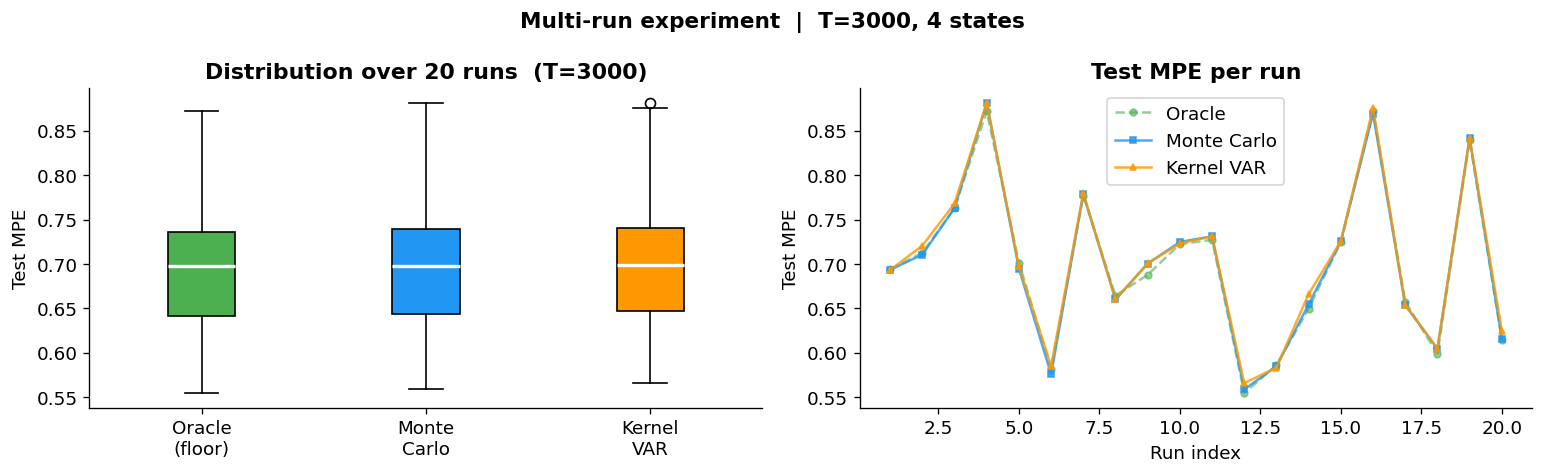

MC wins in 12/20 runs | KernelVAR wins in 8/20 runs


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: box plots
data   = [oracle_arr, mc_arr, kvar_arr]
labels = ['Oracle\n(floor)', 'Monte\nCarlo', 'Kernel\nVAR']
colors = ['#4CAF50', '#2196F3', '#FF9800']
bp     = axes[0].boxplot(data, patch_artist=True, medianprops=dict(color='white', linewidth=2))
for patch, col in zip(bp['boxes'], colors):
    patch.set_facecolor(col)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Test MPE')
axes[0].set_title(f'Distribution over {N_RUNS} runs  (T={T})', fontweight='bold')

# Right: run-by-run comparison
runs_x = np.arange(1, N_RUNS + 1)
axes[1].plot(runs_x, oracle_arr, 'o--', color='#4CAF50', alpha=0.6, label='Oracle', markersize=4)
axes[1].plot(runs_x, mc_arr,     's-',  color='#2196F3', alpha=0.8, label='Monte Carlo', markersize=4)
axes[1].plot(runs_x, kvar_arr,   '^-',  color='#FF9800', alpha=0.8, label='Kernel VAR', markersize=4)
axes[1].set_xlabel('Run index')
axes[1].set_ylabel('Test MPE')
axes[1].set_title('Test MPE per run', fontweight='bold')
axes[1].legend()

plt.suptitle(f'Multi-run experiment  |  T={T}, {N_STATES} states', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

mc_wins = int(np.sum(mc_arr < kvar_arr))
print(f'MC wins in {mc_wins}/{N_RUNS} runs | KernelVAR wins in {N_RUNS - mc_wins}/{N_RUNS} runs')

---
## 📈 Experiment 2 — Effect of Trajectory Length $T$

**Key question:** how does each method's error decrease as we get more data?

Expected behaviour:
- Both methods converge to the oracle floor.
- MC should converge at rate $O(1/\sqrt{n_x})$ where $n_x$ is visits to state $x$.
- Kernel VAR convergence depends on its kernel bandwidth — it may start better (smoothing helps small $T$) but may converge slower.

In [14]:
sweep_results = {T_val: {'mc': [], 'kvar': [], 'oracle': []} for T_val in T_VALUES}

SWEEP_RUNS = max(5, N_RUNS // 2)  # fewer runs for speed in sweep

for T_val in T_VALUES:
    print(f'T={T_val}...', end=' ', flush=True)
    for run in range(SWEEP_RUNS):
        rng_s = np.random.default_rng(BASE_SEED + 100 + run)
        X_s   = generate_trajectory(P_TRUE, T_val, rng_s)
        tr, va, te = split_trajectory(X_s, TRAIN_FRAC, VAL_FRAC)
        if len(te) < 2:
            continue

        mc_s = MonteCarloCE(N_STATES).fit(tr)
        bs, bl, _, _ = tune_kernel_var(tr, va, N_STATES, SIGMA_GRID, LAMBDA_GRID)
        kv_s = KernelVAR(N_STATES, sigma=bs, lam=bl).fit(tr)

        sweep_results[T_val]['mc'].append(mc_s.mpe(te))
        sweep_results[T_val]['kvar'].append(kv_s.mpe(te))
        sweep_results[T_val]['oracle'].append(oracle_error(P_TRUE, te))

    mc_mean = np.nanmean(sweep_results[T_val]['mc'])
    kv_mean = np.nanmean(sweep_results[T_val]['kvar'])
    print(f'MC={mc_mean:.4f}  KV={kv_mean:.4f}')

print('Sweep done ✓')

T=200... MC=0.7311  KV=0.7488
T=500... MC=0.6893  KV=0.7068
T=1000... MC=0.6805  KV=0.6827
T=2000... MC=0.6869  KV=0.6946
T=5000... MC=0.7148  KV=0.7179
Sweep done ✓


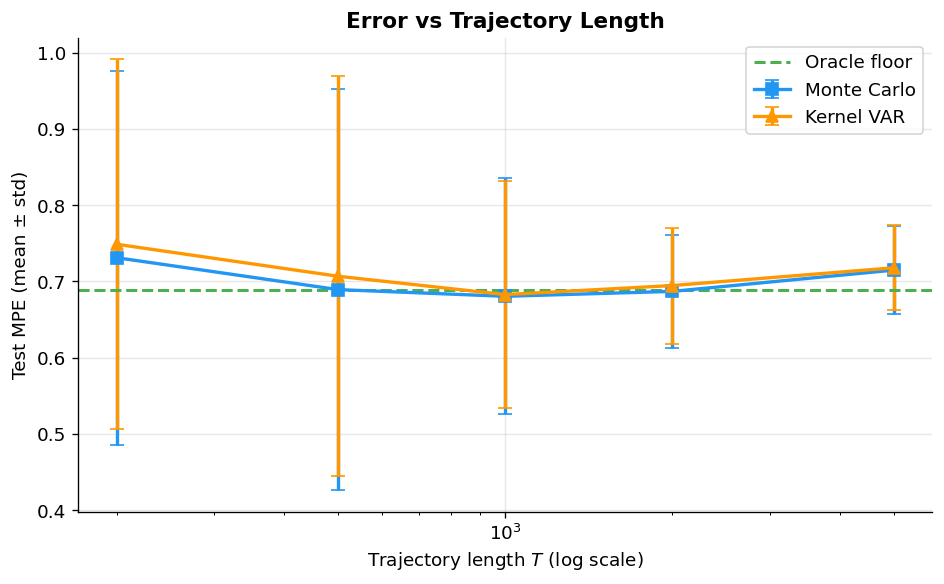

In [15]:
mc_means   = [np.nanmean(sweep_results[T_val]['mc'])     for T_val in T_VALUES]
kvar_means = [np.nanmean(sweep_results[T_val]['kvar'])    for T_val in T_VALUES]
mc_stds    = [np.nanstd (sweep_results[T_val]['mc'])      for T_val in T_VALUES]
kvar_stds  = [np.nanstd (sweep_results[T_val]['kvar'])    for T_val in T_VALUES]
oracle_mean= np.nanmean([v for T_val in T_VALUES for v in sweep_results[T_val]['oracle']])

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(T_VALUES, mc_means,   yerr=mc_stds,   fmt='s-', color='#2196F3',
            label='Monte Carlo', capsize=4, linewidth=2, markersize=7)
ax.errorbar(T_VALUES, kvar_means, yerr=kvar_stds, fmt='^-', color='#FF9800',
            label='Kernel VAR', capsize=4, linewidth=2, markersize=7)
ax.axhline(oracle_mean, color='#4CAF50', linestyle='--', linewidth=1.8,
           label='Oracle floor')

ax.set_xscale('log')
ax.set_xlabel('Trajectory length $T$ (log scale)')
ax.set_ylabel('Test MPE (mean ± std)')
ax.set_title('Error vs Trajectory Length', fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 📝 Summary & Discussion

### What to write about / think about

**Irreducible error floor:**  
Even with infinite data, the best possible MPE is not zero — it equals the
variance of $X_{t+1}$ given $X_t$, since the transition is stochastic.
This *oracle* line in the plots is your reference.

**Why Monte Carlo is natural here:**  
For a *finite-state* chain, MC is the maximum-likelihood estimator of the
conditional expectation. It has no bias and its variance shrinks as $O(1/n_x)$.
Given enough data, it is hard to beat.

**When does Kernel VAR shine?**  
- For **very small T**: some states may not be visited in training; MC returns NaN,
  but Kernel VAR can still interpolate from nearby states.
- If the chain's dynamics have a smooth structure that matches the RBF kernel's
  ordering assumption (e.g., `PRESET_STICKY` or `PRESET_CYCLE`).

**When does Kernel VAR fail?**  
- When the labelling of states is arbitrary and nearby integer labels do not
  correspond to similar dynamics (e.g., `PRESET_CLUSTERS` with states 1 and 2
  behaving very differently from state 0 even though they are close in value).
- With a bad choice of $\sigma$: too small → overfitting; too large → underfitting.

**Suggested experiments:**  
1. Try all four presets and observe how the winner changes.
2. Shrink $T$ to 200 — does MC break down for any state? Does Kernel VAR help?
3. Try a 6-state or 8-state chain.
4. Set `PRESET_UNIFORM` (near-random chain): both methods should hover near
   the oracle floor — why?

---
*Notes: Lorenzo Rosasco — Sequential Prediction as Learning Dynamical Systems.*